# Analisi — Quanto conta il prezzo su Steam?

Il notebook legge il file prodotto da `preprocessing.ipynb`. I dati grezzi non
vengono mai letti qui.

Il progetto risponde a tre domande:

**[D1]** Fra i giochi a pagamento, quelli che costano di più hanno recensioni migliori?

**[D2]** Il punteggio delle recensioni varia fra i generi?

**[D3]** I free-to-play reggono ancora il confronto con i giochi a pagamento?

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

sns.set(style="whitegrid", font_scale=1.2)

# codice colore usato in TUTTI i grafici del progetto
COLORI = {"A pagamento": "#4C72B0", "Free-to-play": "#DD8452"}

## 1. Lettura dei dati ed esclusione dei record non validi

Durante il preprocessing sono state individuate diverse anomalie nei dati senza però eliminarle. L'esclusione avviene qui:

- **102 giochi senza dati di recensione**, identificati da `Numero di recensioni == 0` (include i 5 preordini e 1 data non interpretabile)
- **4 giochi**, con punteggio a 0% pur avendo recensioni.
- **1 riga con data non interpretabile residua** (convertita in `NaT`, esclusa in automatico dal controllo cronologico).

Il campione analizzabile scende così da 1.000 a **893 giochi**. 

*(Nota: i 3 titoli con genere "Unknown" e i titoli con 0 giocatori attivi non vengono scartati in questo passaggio iniziale, ma gestiti con filtri dedicati nelle sezioni [D2] e [D3] dove quelle specifiche colonne entrano in gioco).*

In [2]:
dati_puliti = pd.read_parquet("preprocessed/steam_pulito.parquet")

data_approssimativa_raccolta = pd.Timestamp("2026-03-31")

senza_recensioni = dati_puliti["Numero di recensioni"] == 0
punteggio_zero   = (dati_puliti["Recensioni positive (%)"] == 0) & ~senza_recensioni
data_esclusa     = ~(dati_puliti["Data di uscita"] <= data_approssimativa_raccolta)

print("senza recensioni:        ", senza_recensioni.sum())
print("punteggio zero, in più:  ", punteggio_zero.sum())
print("data esclusa, in più:    ", (data_esclusa & ~senza_recensioni & ~punteggio_zero).sum())

dati = dati_puliti[
    (dati_puliti["Numero di recensioni"] > 0)
    & (dati_puliti["Recensioni positive (%)"] > 0)
    & (dati_puliti["Data di uscita"] <= data_approssimativa_raccolta)
].copy()

print("giochi nel file pulito:", len(dati_puliti))
print("giochi rimossi:", len(dati_puliti) - len(dati))
print("giochi analizzati:    ", len(dati))

senza recensioni:         102
punteggio zero, in più:   4
data esclusa, in più:     1
giochi nel file pulito: 1000
giochi rimossi: 107
giochi analizzati:     893


### 1.1 Variabili costruite per l'analisi

Per rispondere a [D3] servono due variabili che nei dati non ci sono.

**Modello di prezzo**: un gioco è considerato free-to-play se il prezzo di listino
è zero. Questa definizione non distingue i giochi gratuiti da quelli con
acquisti interni, informazione che il dataset non contiene.

**Giocatori per recensione**: giocatori simultanei divisi per numero di recensioni.
Poggia sull'ipotesi che il numero di recensioni approssimi la dimensione del
pubblico: sotto questa ipotesi il rapporto stima quale frazione del pubblico sta
ancora giocando, a differenza del numero assoluto di giocatori, che premierebbe
soltanto i titoli più diffusi. L'ipotesi è discutibile ed è il punto più fragile
dell'analisi.

In [3]:
dati["Modello di prezzo"] = dati["Prezzo (USD)"].apply(
    lambda prezzo: "Free-to-play" if prezzo == 0 else "A pagamento"
)

dati["Giocatori per recensione"] = (dati["Giocatori simultanei (picco 24h)"]
                                    / dati["Numero di recensioni"])

dati["Modello di prezzo"].value_counts()

Modello di prezzo
A pagamento     843
Free-to-play     50
Name: count, dtype: int64

I free-to-play analizzabili sono **50**, mentre nella classifica completa erano
108: per 56 i dati di recensione mancavano, come documentato nella sezione
2.3 del preprocessing, e altri 2 hanno un punteggio incoerente con il numero di recensioni (sezione 2.6). I risultati di **[D3]** valgono quindi su meno della metà dei
free-to-play presenti in classifica ed è un limite che questi dati non permettono
di correggere.

## 2. [D1] Fra i giochi a pagamento, quelli che costano di più hanno recensioni migliori?

Il confronto è fra prezzo e percentuale di recensioni positive. I free-to-play sono esclusi perché non sono giochi molto economici ma un modello di business diverso, con un pubblico che entra senza barriera e ricavi che arrivano da altro. Metterli sulla stessa scala dei prezzi confonderebbe due domande, e infatti sono il soggetto di **[D3]**.

In [4]:
a_pagamento = dati[dati["Modello di prezzo"] == "A pagamento"]

corr_pearson, _ = pearsonr(a_pagamento["Prezzo (USD)"],
                           a_pagamento["Recensioni positive (%)"])
corr_spearman, _ = spearmanr(a_pagamento["Prezzo (USD)"],
                             a_pagamento["Recensioni positive (%)"])

print("giochi a pagamento:", len(a_pagamento))
print(f"Pearson  r = {corr_pearson:+.3f}")
print(f"Spearman r = {corr_spearman:+.3f}")

giochi a pagamento: 843
Pearson  r = -0.230
Spearman r = -0.274


Vengono calcolati entrambi i coefficienti per verificare la natura del legame: Pearson individua le relazioni lineari, mentre Spearman valuta l'esistenza di una generica relazione monotona basandosi sui ranghi.

L'indice di Spearman (−0,274) risulta più marcato rispetto a quello di Pearson (−0,230). Il gradimento non decresce a passo costante lungo la scala dei prezzi, come mostrano i grafici seguenti.

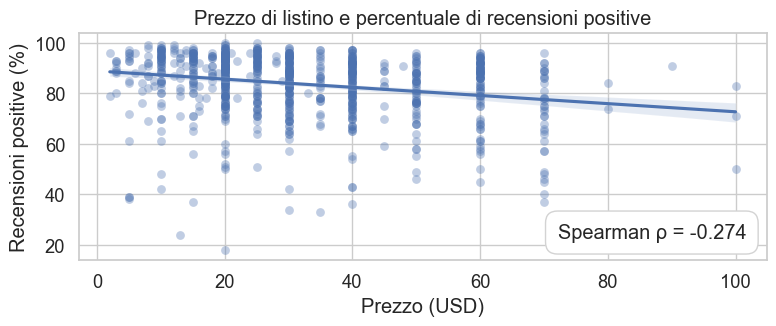

In [5]:
plt.figure(figsize=(8, 3.5))
sns.regplot(data=a_pagamento, x="Prezzo (USD)", y="Recensioni positive (%)",
            scatter_kws={"s": 40, "alpha": 0.35, "linewidths": 0},
            line_kws={"color": COLORI["A pagamento"]})
plt.annotate(f"Spearman ρ = {corr_spearman:.3f}",
             xy=(0.97, 0.08), xycoords="axes fraction", ha="right", va="bottom",
             bbox=dict(boxstyle="round,pad=0.6", fc="white", ec="lightgrey"))
plt.title("Prezzo di listino e percentuale di recensioni positive")
plt.tight_layout();

I punti si dispongono in colonne verticali perché i prezzi su Steam non sono
continui, ma si concentrano su pochi valori di listino: 20, 30, 40 e 60 dollari
coprono la maggior parte del catalogo. Con 843 titoli sovrapposti la dispersione
nasconde l'andamento, che si legge meglio raggruppando per fasce di prezzo.

In [6]:
per_fascia = a_pagamento.copy()
per_fascia["Fascia di prezzo (USD)"] = pd.cut(
    per_fascia["Prezzo (USD)"],
    bins=[0, 10, 20, 30, 40, 60, 100],
    labels=["≤10", "10–20", "20–30", "30–40", "40–60", ">60"],
)

riepilogo_fasce = per_fascia.groupby("Fascia di prezzo (USD)", observed=True)[
    "Recensioni positive (%)"].agg(["size", "median"])
riepilogo_fasce.columns = ["n", "mediana (%)"]
riepilogo_fasce

,n,mediana (%)
Fascia di prezzo (USD),,
≤10,91,91.0
10–20,233,90.0
20–30,191,88.0
30–40,139,85.0
40–60,148,85.0
>60,41,75.0


Le fasce sono costruite con `pd.cut`, che divide una variabile continua in
intervalli. All'interno di ciascuna viene calcolata la mediana, più robusta della
media rispetto ai valori estremi.

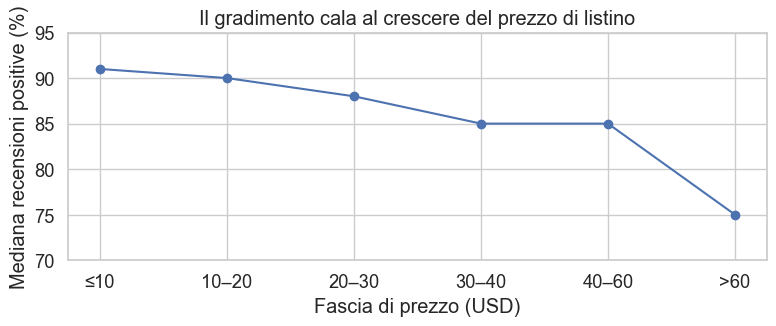

In [7]:
plt.figure(figsize=(8, 3.5))
riepilogo_fasce["mediana (%)"].plot(marker="o", color=COLORI["A pagamento"])
plt.ylabel("Mediana recensioni positive (%)")
plt.ylim(70, 95)
plt.title("Il gradimento cala al crescere del prezzo di listino")
plt.tight_layout();

L'asse verticale è ristretto all'intervallo osservato per evidenziare la pendenza: trattandosi di un grafico a linee, a essere letta è la direzione dell'andamento e non l'ampiezza assoluta dei valori.

Il punteggio decresce lungo tutte le fasce, dal **91%** dei titoli sotto i 10 dollari al **75%** di quelli sopra i 60, con uno scarto di **16 punti percentuali**. La flessione resta però contenuta fino ai 60 dollari e si accentua solo nell'ultima fascia, che raccoglie 41 titoli ed è quindi quella con la stima meno stabile.

Fra i titoli a pagamento analizzati, a un prezzo di listino più alto corrisponde in
media una percentuale di recensioni positive inferiore. Il prezzo spiega tuttavia
appena il **5,3%** della variabilità ($r^2$ di Pearson): il restante **95%** dipende da
variabili esterne a questi dati, e titoli con valutazioni eccellenti sono distribuiti
lungo tutte le fasce di prezzo.

## 3. [D2] Il punteggio delle recensioni varia fra i generi?

Il raggruppamento usa `Genere Primario` e non i tag: questi ultimi sono troncati ai
primi dieci (sezione 2.5 del preprocessing) e sono stati eliminati.

Vengono tenuti solo i generi con almeno 20 titoli: sotto quella soglia la mediana di
un gruppo diventa poco affidabile. La soglia esclude anche i giochi con genere `Unknown`, che sarebbero comunque da scartare.

In [8]:
conteggio_generi = dati["Genere Primario"].value_counts()
generi_validi = conteggio_generi[conteggio_generi >= 20].index

per_genere = dati[dati["Genere Primario"].isin(generi_validi)]

riepilogo_generi = (per_genere.groupby("Genere Primario")
                    .agg(**{"n": ("AppID", "size"),
                            "mediana (%)": ("Recensioni positive (%)", "median"),
                            "prezzo mediano": ("Prezzo (USD)", "median")})
                    .sort_values("mediana (%)"))
riepilogo_generi

,n,mediana (%),prezzo mediano
Genere Primario,,,
Simulation,45,80.0,30.0
RPG,65,84.0,35.0
Action,519,86.0,30.0
Strategy,25,88.0,30.0
Adventure,94,89.0,25.0
Casual,55,92.0,18.0
Indie,61,93.0,20.0


Il campione è molto sbilanciato: *Action* da solo vale più della metà dei titoli
in classifica. È un fatto sul mercato, non un difetto dei dati, ma va tenuto presente
leggendo il grafico, i generi meno numerosi hanno mediane meno stabili.

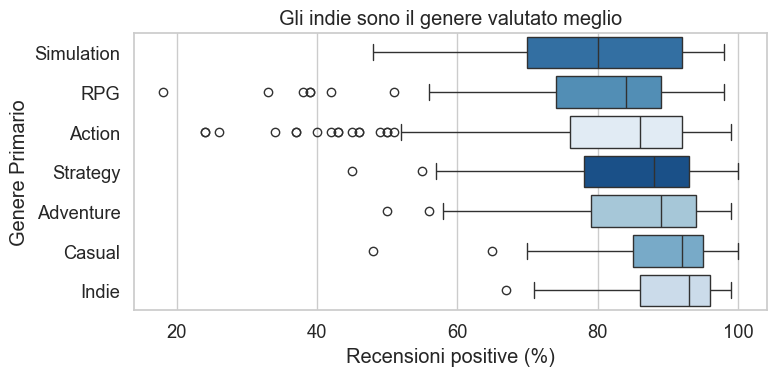

In [9]:
ordine_generi = riepilogo_generi.index.tolist()

plt.figure(figsize=(8, 4))
sns.boxplot(data=per_genere, x="Recensioni positive (%)", y="Genere Primario",
            order=ordine_generi, hue="Genere Primario", legend=False, palette="Blues")
plt.title("Gli indie sono il genere valutato meglio")
plt.tight_layout();

La mediana va dall'**80% di *Simulation*** al **93% di *Indie***. Il boxplot mostra che non si tratta
solo di uno spostamento della mediana: le distribuzioni hanno forme diverse e
*Simulation* ha una coda molto più lunga verso i punteggi bassi.

**Il genere è associato al gradimento**. Gli *Indie* risultano
il genere valutato meglio pur essendo fra i meno numerosi in classifica: sono pochi a
entrare fra i più venduti, ma quelli che ci riescono piacciono molto.

**Attenzione**: il confronto è fra *gli Indie di successo* e *gli Action di
successo*, non fra *tutti gli indie* e *tutti gli action* del catalogo Steam.

## 4. [D3] I free-to-play reggono il confronto con i giochi a pagamento?

"Reggere" può significare due cose diverse (piacere ai giocatori, oppure essere
ancora giocati) e le due misure danno risposte opposte.

### 4.1 Il gradimento

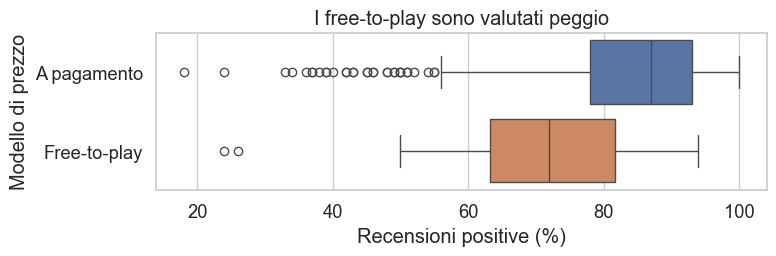

In [10]:
plt.figure(figsize=(8, 2.8))
sns.boxplot(data=dati, x="Recensioni positive (%)", y="Modello di prezzo",
            hue="Modello di prezzo", palette=COLORI, legend=False,
            order=["A pagamento", "Free-to-play"])
plt.title("I free-to-play sono valutati peggio")
plt.tight_layout();

In [11]:
dati.groupby("Modello di prezzo")["Recensioni positive (%)"] \
    .agg(**{"n": "size", "mediana": "median"})

,n,mediana
Modello di prezzo,,
A pagamento,843,87.0
Free-to-play,50,72.0


Mediana **72% contro 87%**: quindici punti percentuali di scarto. Il boxplot
mostra che la distribuzione dei free-to-play è spostata verso il basso su tutta la
sua estensione, non solo nella mediana.

### 4.2 L'attività

Il confronto usa i giocatori per recensione definiti nella sezione 1.1. Vengono
considerati solo i titoli con almeno un giocatore al momento della rilevazione: sono esclusi i
giochi documentati nella sezione 2.7 del preprocessing, su cui il valore zero è
incoerente con il numero di recensioni della stessa riga. L'esclusione è necessaria
anche tecnicamente, perché lo zero non è rappresentabile su scala logaritmica.

In [12]:
attivi = dati[dati["Giocatori per recensione"] > 0]

esclusi = (dati.groupby("Modello di prezzo")
           .agg(**{"totale": ("AppID", "size"),
                   "con giocatori": ("Giocatori simultanei (picco 24h)",
                                     lambda col: (col > 0).sum())}))
esclusi["esclusi"] = esclusi["totale"] - esclusi["con giocatori"]
esclusi["quota esclusi %"] = (esclusi["esclusi"] / esclusi["totale"] * 100).round(1)
esclusi

,totale,con giocatori,esclusi,quota esclusi %
Modello di prezzo,,,,
A pagamento,843,630,213,25.3
Free-to-play,50,43,7,14.0


L'esclusione è asimmetrica: 25% fra i giochi a pagamento contro 14% fra i free-to-play. Poiché i titoli esclusi sono quelli con attività nulla, la mediana dei giochi a pagamento si alza più di quella dei free-to-play. Il divario calcolato è quindi una stima prudente: con i dati completi sarebbe verosimilmente più ampio. 

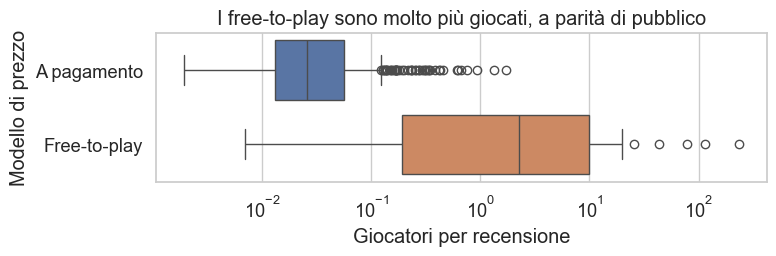

In [13]:
plt.figure(figsize=(8, 2.8))
sns.boxplot(data=attivi, x="Giocatori per recensione", y="Modello di prezzo",
            hue="Modello di prezzo", palette=COLORI, legend=False,
            order=["A pagamento", "Free-to-play"])
plt.xscale("log")   # le due distribuzioni differiscono di ordini di grandezza
plt.title("I free-to-play sono molto più giocati, a parità di pubblico")
plt.tight_layout();

In [14]:
mediane_attivita = attivi.groupby("Modello di prezzo")["Giocatori per recensione"].median()

print(mediane_attivita.round(4).to_string())
print(f"\nrapporto fra le mediane: "
      f"{mediane_attivita['Free-to-play'] / mediane_attivita['A pagamento']:.0f}x")

Modello di prezzo
A pagamento     0.0259
Free-to-play    2.2466

rapporto fra le mediane: 87x


La mediana dei free-to-play è 87 volte superiore a quella dei titoli a pagamento. La scala logaritmica è necessaria perché su scala lineare i giochi a pagamento risulterebbero schiacciati contro l'asse.

Nel complesso i due modelli mostrano dinamiche opposte: i free-to-play hanno valutazioni inferiori ma un livello di attività per recensione molto più alto.

Il confronto presenta due limiti: si basa su 43 free-to-play, dei 108 presenti in classifica, e la rilevazione dei giocatori è circoscritta a un singolo giorno, quindi risente di eventi o aggiornamenti in corso.

## 5. Conclusioni

**[D1]** Fra i giochi a pagamento, a un prezzo di listino più alto corrisponde una
percentuale di recensioni positive inferiore: si passa dal 91% dei titoli sotto i 10
dollari al 75% di quelli sopra i 60. Il prezzo spiega tuttavia solo il 5,3% della
variabilità complessiva.

**[D2]** Il gradimento varia sensibilmente fra i generi: la mediana delle recensioni
positive spazia dall'80% di *Simulation* al 93% di *Indie*, con uno scarto di tredici
punti percentuali.

**[D3]** I titoli free-to-play registrano una valutazione mediana inferiore di
quindici punti percentuali rispetto ai giochi a pagamento, ma a parità di pubblico
stimato mostrano un'attività di giocatori simultanei 87 volte superiore.

### Due scoperte sui dati

`Estimated_Owners` non costituiva una rilevazione empirica: equivaleva esattamente a
`Total_Reviews * 30` sull'intero dataset. Impiegare questa variabile avrebbe
significato replicare il volume delle recensioni sotto l'apparenza delle vendite
effettive.

`Price_USD` registrava il prezzo promozionale al momento del crawling anziché il
listino base: 342 titoli su 1.000 erano scontati. Scorporando lo sconto per
ricostruire il prezzo nominale, la correlazione di **[D1]** emerge con maggiore
chiarezza.

### Limiti dell'analisi

1. Il campione raccoglie i mille titoli più venduti: i risultati descrivono le
   dinamiche interne ai titoli di successo commerciale e non sono generalizzabili
   all'intero catalogo Steam.
2. I confronti su **[D3]** poggiano su 50 free-to-play dei 108 presenti in classifica,
   e l'analisi sul picco di attività si riduce ulteriormente a 43 titoli.
3. La metrica sui giocatori simultanei (picco 24h) risulta nulla su circa un terzo
   delle osservazioni e riflette un unico intervallo giornaliero, risentendo di eventi
   occasionali come aggiornamenti o promozioni.
4. Il prezzo di listino di 342 titoli deriva da una ricostruzione a ritroso e non da
   una misura diretta.
5. Le associazioni evidenziate descrivono correlazioni fra grandezze rilevate nel
   medesimo istante e non implicano nessi di causalità.